ДР 6. Группа 10. Кластерный анализ Детская молочная продукция. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('sales_and_stock_2024_12.csv', on_bad_lines='skip', delimiter=';', encoding='utf-8', engine='python')

In [ ]:
df.head(10)

,TransDate,ShopCode,ShopFormat,City,Region,ItemName,ItemLevelName1,ItemLevelName2,SalesQty,SalesAmount,StockQty
0,2024-12-01,2437,2,Город-025,Регион-005,"Вино 0,75л Villa Krim Orange Fox Bay ЗГУ Крым ...",Алкогольные напитки,Вино,0.0,0.00000,7.0
1,2024-12-01,2100,2,Город-025,Регион-005,"Водка 0,7л Царь 40% ст/бут",Алкогольные напитки,"Водка, настойки",0.0,0.00000,7.0
2,2024-12-01,5580,5,Город-016,Регион-002,Сыр плавленый 150 г Hochland Ассорти 45% м/уп,Молочная гастрономия,Сыры,1.0,218.58379,10.0
3,2024-12-01,370,3,Город-036,Регион-007,"Водка 0,5л Русская Валюта 38% ст/бут",Алкогольные напитки,"Водка, настойки",0.0,0.00000,26.0
4,2024-12-01,3830,3,Город-021,Регион-004,"Коньяк 0,5л Коктебель 5-летний 40% ст/бут",Алкогольные напитки,"Коньяк, бренди",0.0,0.00000,16.0
5,2024-12-01,280,2,Город-036,Регион-007,"Вино 0,75л Casa San Nicola красное сухое ст/бу...",Алкогольные напитки,Вино,0.0,0.00000,10.0
6,2024-12-01,3881,3,Город-021,Регион-004,Вино 187мл Бухта Омега Каберне красное сухое с...,Алкогольные напитки,Вино,0.0,0.00000,7.0
7,2024-12-01,2286,2,Город-037,Регион-008,"Настойка 0,5л AMG Грейпфрут с Лимоном полуслад...",Алкогольные напитки,"Водка, настойки",0.0,0.00000,13.0
8,2024-12-01,3180,3,Город-029,Регион-003,"Водка 0,5л Хаски Nordic Currant 40% ст/бут",Алкогольные напитки,"Водка, настойки",0.0,0.00000,9.0
9,2024-12-01,103,0,Город-016,Регион-002,"Вино 0,75л Круча ЗГУ Кубань белое сухое ст/бут",Алкогольные напитки,Вино,0.0,0.00000,7.0


In [ ]:
df_filtered = df[df['ItemLevelName2'] == 'Детская молочная продукция']


In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4083 entries, 24 to 187520
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TransDate       4083 non-null   object 
 1   ShopCode        4083 non-null   int64  
 2   ShopFormat      4083 non-null   int64  
 3   City            4083 non-null   object 
 4   Region          4083 non-null   object 
 5   ItemName        4083 non-null   object 
 6   ItemLevelName1  4083 non-null   object 
 7   ItemLevelName2  4083 non-null   object 
 8   SalesQty        4083 non-null   float64
 9   SalesAmount     4083 non-null   float64
 10  StockQty        4083 non-null   float64
dtypes: float64(3), int64(2), object(6)
memory usage: 382.8+ KB


In [ ]:
df_filtered.head()

,TransDate,ShopCode,ShopFormat,City,Region,ItemName,ItemLevelName1,ItemLevelName2,SalesQty,SalesAmount,StockQty
24,2024-12-01,277,2,Город-025,Регион-005,"Ряженка 180г Агуша клубника детская 2,9% пл/бут",Молочная гастрономия,Детская молочная продукция,0.0,0.0,6.0
28,2024-12-01,4182,4,Город-034,Регион-006,Молочный коктейль 200 мл ФрутоНяня для пит. де...,Молочная гастрономия,Детская молочная продукция,0.0,0.0,10.0
78,2024-12-01,3830,3,Город-021,Регион-004,Десерт творожный 100г Стеша Банан 5% пл/ст,Молочная гастрономия,Детская молочная продукция,0.0,0.0,4.0
124,2024-12-01,5114,5,Город-040,Регион-004,"Йогурт 180 г Агуша клубника-банан 2,7% питьево...",Молочная гастрономия,Детская молочная продукция,0.0,0.0,5.0
212,2024-12-01,2342,2,Город-025,Регион-005,"Молоко 0,5 кг Тема ультрапастеризованное 3,2% ...",Молочная гастрономия,Детская молочная продукция,0.0,0.0,17.0


In [ ]:
df_filtered.describe()

,ShopCode,ShopFormat,SalesQty,SalesAmount,StockQty
count,4083.000000,4083.000000,4083.000000,4083.000000,4083.000000
mean,2705.021798,2.925545,0.795983,47.616198,7.353417
std,1720.083567,1.133578,1.641203,94.755788,8.496664
min,103.000000,0.000000,0.000000,0.000000,-12.000000
25%,1110.000000,2.000000,0.000000,0.000000,2.000000
50%,3116.000000,3.000000,0.000000,0.000000,5.000000
75%,3881.000000,4.000000,1.000000,65.006790,10.000000
max,5580.000000,5.000000,20.000000,1008.675800,127.000000


In [ ]:
df_filtered.isna().sum()

,0
TransDate,0
ShopCode,0
ShopFormat,0
City,0
Region,0
ItemName,0
ItemLevelName1,0
ItemLevelName2,0
SalesQty,0
SalesAmount,0


In [ ]:
df_filtered.duplicated().sum()

np.int64(0)

In [ ]:
print('Размер данных после фильтрации:', df_filtered.shape)
display(df_filtered.head())
print('Категории ItemLevelName2:')
display(df_filtered['ItemLevelName2'].value_counts(dropna=False))
print('Период:', df_filtered['TransDate'].min(), '-', df_filtered['TransDate'].max())
print('Количество магазинов:', df_filtered['ShopCode'].nunique())
print('Количество товаров:', df_filtered['ItemName'].nunique())

Размер данных после фильтрации: (4083, 11)


,TransDate,ShopCode,ShopFormat,City,Region,ItemName,ItemLevelName1,ItemLevelName2,SalesQty,SalesAmount,StockQty
24,2024-12-01,277,2,Город-025,Регион-005,"Ряженка 180г Агуша клубника детская 2,9% пл/бут",Молочная гастрономия,Детская молочная продукция,0.0,0.0,6.0
28,2024-12-01,4182,4,Город-034,Регион-006,Молочный коктейль 200 мл ФрутоНяня для пит. де...,Молочная гастрономия,Детская молочная продукция,0.0,0.0,10.0
78,2024-12-01,3830,3,Город-021,Регион-004,Десерт творожный 100г Стеша Банан 5% пл/ст,Молочная гастрономия,Детская молочная продукция,0.0,0.0,4.0
124,2024-12-01,5114,5,Город-040,Регион-004,"Йогурт 180 г Агуша клубника-банан 2,7% питьево...",Молочная гастрономия,Детская молочная продукция,0.0,0.0,5.0
212,2024-12-01,2342,2,Город-025,Регион-005,"Молоко 0,5 кг Тема ультрапастеризованное 3,2% ...",Молочная гастрономия,Детская молочная продукция,0.0,0.0,17.0


Категории ItemLevelName2:


,count
ItemLevelName2,
Детская молочная продукция,4083


Период: 2024-12-01 - 2024-12-02
Количество магазинов: 67
Количество товаров: 121


In [ ]:
store_abs = df_filtered.groupby('ShopCode').agg(
    sales_qty_total=('SalesQty', 'sum'),
    revenue_total=('SalesAmount', 'sum'),
    mean_stock_qty=('StockQty', 'mean'),
    median_stock_qty=('StockQty', 'median'),
    max_stock_qty=('StockQty', 'max'),
    unique_products_count=('ItemName', 'nunique'),
    active_days_count=('TransDate', 'nunique'),
    ShopFormat=('ShopFormat', 'first'),
    City=('City', 'first'),
    Region=('Region', 'first'),
).reset_index()

store_abs['avg_revenue_per_unit'] = store_abs['revenue_total'] / store_abs['sales_qty_total']
store_abs['revenue_per_active_day'] = store_abs['revenue_total'] / store_abs['active_days_count'].replace(0, np.nan)
store_abs['sales_qty_per_active_day'] = store_abs['sales_qty_total'] / store_abs['active_days_count'].replace(0, np.nan)
store_abs = store_abs.replace([np.inf, -np.inf], np.nan).fillna(0)

display(store_abs.head())
print('Количество строк в store_abs:', len(store_abs))

# Исключаем ShopCode (идентификатор) и ShopFormat (категориальный код).
features = [
    'revenue_total',
    'sales_qty_total',
    'mean_stock_qty',
    'unique_products_count',
    'avg_revenue_per_unit',
    'sales_qty_per_active_day',
]
df_num = store_abs[features].copy()
print('Признаки для кластеризации:', features)


,ShopCode,sales_qty_total,revenue_total,mean_stock_qty,median_stock_qty,max_stock_qty,unique_products_count,active_days_count,ShopFormat,City,Region,avg_revenue_per_unit,revenue_per_active_day,sales_qty_per_active_day
0,103,4.0,188.28316,6.909091,2.0,20.0,6,2,0,Город-016,Регион-002,47.070790,94.141580,2.0
1,106,16.0,829.36064,14.647059,16.0,22.0,10,2,0,Город-016,Регион-002,51.835040,414.680320,8.0
2,265,36.0,2091.38244,10.097561,8.0,38.0,23,2,2,Город-025,Регион-005,58.093957,1045.691220,18.0
3,271,19.0,1083.79401,5.673913,4.0,15.0,28,2,2,Город-021,Регион-004,57.041790,541.897005,9.5
4,277,39.0,2341.90352,4.901235,4.0,17.0,44,2,2,Город-025,Регион-005,60.048808,1170.951760,19.5


Количество строк в store_abs: 67
Признаки для кластеризации: ['revenue_total', 'sales_qty_total', 'mean_stock_qty', 'unique_products_count', 'avg_revenue_per_unit', 'sales_qty_per_active_day']


In [ ]:
store_abs.to_csv('store_abs.csv')

## Стандартизация

In [ ]:
# Стандартизация: DBSCAN основан на расстояниях,
# поэтому разные масштабы признаков искажают результаты кластеризации.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

print('Форма матрицы признаков:', X_scaled.shape)


Форма матрицы признаков: (67, 6)


## Найдите оптимальную EPS, используя график «локтя» (k-расстояние).

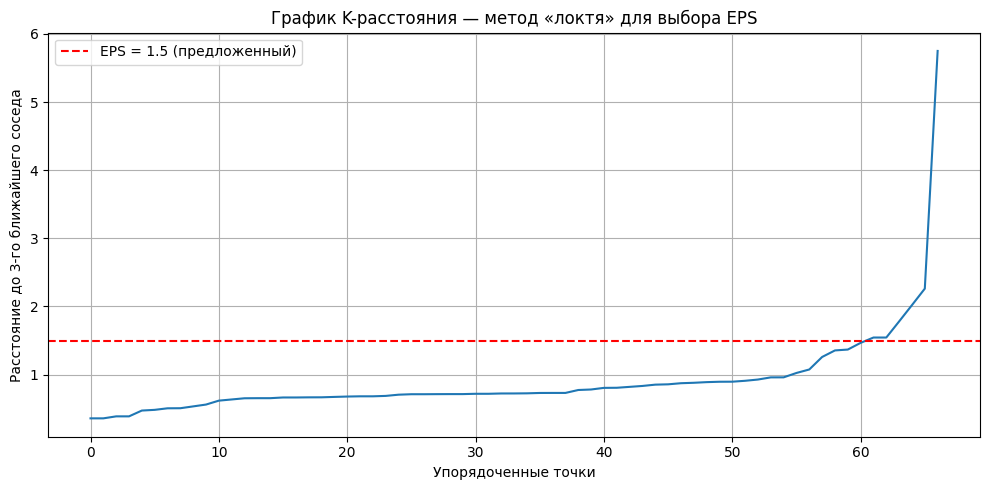

In [ ]:
k = 3

nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

distances_k = np.sort(distances[:, k - 1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances_k)
plt.axhline(y=1.5, color='red', linestyle='--', label='EPS = 1.5 (предложенный)')
plt.xlabel('Упорядоченные точки')
plt.ylabel(f'Расстояние до {k}-го ближайшего соседа')
plt.title('График K-расстояния — метод «локтя» для выбора EPS')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### DBSCAN

In [ ]:
eps_value = 1.5
min_samples_value = 3

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f'Количество кластеров: {n_clusters}')
print(f'Шумовые точки (выбросы): {n_noise} ({n_noise / len(labels) * 100:.1f}%)')
print(f'Распределение по кластерам:\n{pd.Series(labels).value_counts().sort_index()}')

if n_clusters > 1:
    sil = silhouette_score(X_scaled, labels)
    print(f'Силуэтный коэффициент: {sil:.3f}')


Количество кластеров: 2
Шумовые точки (выбросы): 4 (6.0%)
Распределение по кластерам:
-1     4
 0    54
 1     9
Name: count, dtype: int64
Силуэтный коэффициент: 0.503


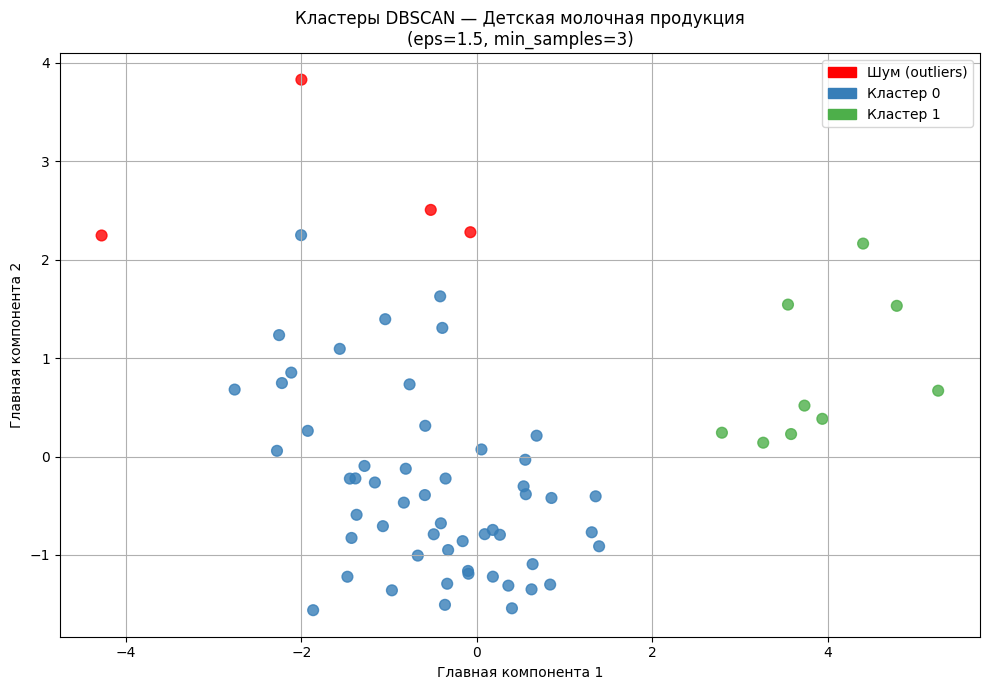

Объяснённая дисперсия (PC1 + PC2): 81.4%


In [ ]:
import matplotlib.patches as mpatches

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

color_map = {-1: 'red', 0: '#377eb8', 1: '#4daf4a'}
point_colors = [color_map[l] for l in labels]

plt.figure(figsize=(10, 7))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=point_colors, s=60, alpha=0.8)

patches = [
    mpatches.Patch(color='red',     label='Шум (outliers)'),
    mpatches.Patch(color='#377eb8', label='Кластер 0'),
    mpatches.Patch(color='#4daf4a', label='Кластер 1'),
]
plt.legend(handles=patches)
plt.title(f'Кластеры DBSCAN — Детская молочная продукция\n'
          f'(eps={eps_value}, min_samples={min_samples_value})')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Объяснённая дисперсия (PC1 + PC2): {pca.explained_variance_ratio_.sum() * 100:.1f}%')

In [ ]:
df_result = store_abs.copy()
df_result['cluster'] = labels

print('Средний профиль каждого кластера (без шумовых точек):')
cluster_profile = (
    df_result[df_result['cluster'] != -1]
    .groupby('cluster')[features]
    .mean()
    .round(2)
)
display(cluster_profile)

print('\nКоличество магазинов в каждом кластере:')
counts = pd.Series(labels).value_counts().sort_index()
counts.index = [f'Шум (outliers)' if i == -1 else f'Кластер {i}' for i in counts.index]
print(counts)


Средний профиль каждого кластера (без шумовых точек):


,revenue_total,sales_qty_total,mean_stock_qty,unique_products_count,avg_revenue_per_unit,sales_qty_per_active_day
cluster,,,,,,
0,2078.25,35.17,7.06,33.89,58.73,17.58
1,8414.94,137.33,9.06,47.22,61.45,68.67



Количество магазинов в каждом кластере:
Шум (outliers)     4
Кластер 0         54
Кластер 1          9
Name: count, dtype: int64


## Интерпретация результатов

In [ ]:
print('=== ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ===\n')

for cluster_id in sorted(set(labels)):
    shops = df_result[df_result['cluster'] == cluster_id]
    n = len(shops)
    if cluster_id == -1:
        print(f'Шумовые точки (outliers): {n} магазинов')
        print('  → Магазины с нетипичным поведением: аномально высокие или низкие продажи.\n')
    else:
        rev   = shops['revenue_total'].mean()
        qty   = shops['sales_qty_total'].mean()
        prods = shops['unique_products_count'].mean()
        spd   = shops['sales_qty_per_active_day'].mean()
        print(f'Кластер {cluster_id}: {n} магазинов')
        print(f'  Средняя выручка:        {rev:>10.0f} руб.')
        print(f'  Среднее кол-во продаж:  {qty:>10.0f} ед.')
        print(f'  Ассортимент:            {prods:>10.0f} уник. товаров')
        print(f'  Продажи в день:         {spd:>10.2f} ед./день')
        print()


=== ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ===

Шумовые точки (outliers): 4 магазинов
  → Магазины с нетипичным поведением: аномально высокие или низкие продажи.

Кластер 0: 54 магазинов
  Средняя выручка:              2078 руб.
  Среднее кол-во продаж:          35 ед.
  Ассортимент:                    34 уник. товаров
  Продажи в день:              17.58 ед./день

Кластер 1: 9 магазинов
  Средняя выручка:              8415 руб.
  Среднее кол-во продаж:         137 ед.
  Ассортимент:                    47 уник. товаров
  Продажи в день:              68.67 ед./день

